In [1]:
#Import packages
using Pkg
using StatsBase
using CSV
using Plots
using DataFrames
using DifferentialEquations
using SciMLSensitivity
using LsqFit
using DifferentialEquations, RecursiveArrayTools, Plots, DiffEqParamEstim
using Optimization, ForwardDiff, OptimizationOptimJL, OptimizationBBO
using BlackBoxOptim

In [2]:
#define logistic model
#HERE ARE SOME TESTER MODELS
function logistic_growth(du, u, p, t)
    r, k = p #parameters always called p
    du[1] = u[1] * r * (1 - u[1] / k) #1 indicated one pop (e.g. only either sens or res)
end

logistic_growth (generic function with 1 method)

In [3]:
#define optimizer
function setUpProblem(modelTypeSet, xdataSet, ydataSet, odeSolver, u0Set, paramSet, tspanSet, boundsSet)
    probSet = ODEProblem(modelTypeSet, u0Set, tspanSet, paramSet)
    #solSet = solve(probSet, odeSolver, saveat=xdataSet, reltol=1e-12, abstol=1e-12) #check into other iterations
    #build_loss_objective creates the cost function; it internally calls the ODE solver to get solutions to test against the data (part of the SciMLBase package)
    cost_functionSet = build_loss_objective(
        probSet, odeSolver,
        L2Loss(xdataSet, ydataSet), #optimized version of the L2-distance (euclidean distane between points); the function (using solution) that optimizer will seek to minimize
        Optimization.AutoForwardDiff(); #automatic differentation for gradient calculations; this is a good choice when there are less than 100 parameters
        maxiters=10000, #this sets the max number of iterations to try before quitting; set somewhat low here; will error out early and not waste our time
        verbose=false #this divergence can get very noisy, so turn off outputs
    )
    
    optsolSet = bboptimize(cost_functionSet; #global opt
                           SearchRange = collect(zip([b[1] for b in boundsSet], [b[2] for b in boundsSet])), 
                           Method = :de_rand_1_bin, 
                           MaxTime = 100.0,     TraceMode = :silent  # <--- suppresses all printing
    )
    
    optimized_paramsSet = best_candidate(optsolSet) #take the best candidates for parameters
    optimized_probSet = ODEProblem(modelTypeSet, [ydataSet[1]], tspanSet, optimized_paramsSet) #resolve and get the probability set using optimized parameters with everything else the same
    xdata_denseSet = range(xdataSet[1], xdataSet[end], length=1000) #break each day up into tiny little bits
    optimized_solSet = solve(optimized_probSet, odeSolver, reltol=1e-12, abstol=1e-12, saveat=xdata_denseSet) #return solutions at each tiny little bit of day
    
    return optimized_paramsSet, optimized_solSet, optimized_probSet
end

setUpProblem (generic function with 1 method)

In [4]:
#Define BIC calculation formula
function calculate_bic(probbic, xdatabic, ydatabic, solverbic, optparbic)
    solbic = solve(probbic, solverbic, reltol=1e-15, abstol=1e-15, saveat=xdatabic)
    residualsbic = [ydatabic[i] - solbic(xdatabic[i])[1] for i in 1:length(xdatabic)]
    ssrbic = sum(residualsbic .^ 2)
    kbic = length(optparbic)
    nbic = length(xdatabic)
    bic = nbic * log(ssrbic / nbic) + kbic * log(nbic)
    return bic, ssrbic
end

calculate_bic (generic function with 1 method)

In [14]:
#combine optimizer and BIC calculation to get all the outputs at once
function singleModel(
    label_cell, x, y, u0,
    label_model1, p1,bounds1, model1,
    solver, 
    tspan;
    output_csv = "ode_solution_uo-300.csv"
)
    # === Solve for model1
    println("===== Solving for Model 1: $label_model1 =====")
    opt_params_model1, opt_sol_model1, opt_prob_model1 = setUpProblem(model1, x, y, solver, u0, p1, tspan, bounds1)
    bic_model1, ssr_model1 = calculate_bic(opt_prob_model1, x, y, solver, opt_params_model1)

    # === Plot overlay
    p = plot(title = "Logistic Model- Resistant Cells", xlabel = "Day", ylabel = "Tumor Cell Count", legend = :bottomright)
    scatter!(p, x, y, label = "Data - $label_cell", color = :blue)
    plot!(p, opt_sol_model1.t, [u[1] for u in opt_sol_model1.u], label = "Model - $label_model1", color = :orange, lw = 2, xlimits = (0,15), ylimits=(0,400000))

    display(p)

    # === Print stats
    println("\n=== Statistical Summary ===")
    println("[$label_model1] Params: ", opt_params_model1)
    println("[$label_model1] BIC: ", bic_model1, " | SSR: ", ssr_model1)
    println("="^60)

    # === Save stats to CSV

     ### df = DataFrame(
     #   Label = [label_model1],
      #  Model = [string(model1)],
      #  Params = [string(opt_params_model1)],
      #  BIC = [bic_model1],
      #  SSR = [ssr_model1]
    #)
    
    df = DataFrame(
        Day = opt_sol_model1.t,
        Count = [u[1] for u in opt_sol_model1.u]
    )
    
    #return opt_sol_model1
    
    CSV.write(output_csv, df) 

   #CSV.write(output_csv, df)
   #println("Results saved to $output_csv")
end

singleModel (generic function with 1 method)

In [6]:
#import data for the 4 curves to calculate the logistic growth
x_all = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]

y_tyk_untreated = [300.3795849,9965.824655,30518.2284,44526.71771,104935.9159,153316.754,198661.7257,250461.324,249645.7234,209727.7897,255186.1547,253730.7756,303022.9253,263526.1739,291107.4779]
y_tykcpr_untreated = [300.3795849,5507.122263,12091.96042,17238.28775,37998.48809,65437.29207,111137.5327,170813.7146,215865.3456,302535.6695,234693.2181,339526.1538,223661.7378,320148.6067,240176.0166]

y_tyk_M2TAM = [300.3795849,17674.39185,40737.99997,43287.0812,75324.58649,91195.85276,134754.5472,143017.3688,178166.9968,139661.5781,177513.5511,145775.0236,184897.442,189458.5057,241081.5309]
y_tykcpr_M2TAM = [300.3795849,6092.660198,13941.5377,15897.41331,25154.48232,30832.43046,52238.47293,70343.71224,96741.36053,140353.5526,190802.0435,278148.1114,237989.1131,371540.1094,371855.3077]

15-element Vector{Float64}:
    300.3795849
   6092.660198
  13941.5377
  15897.41331
  25154.48232
  30832.43046
  52238.47293
  70343.71224
  96741.36053
 140353.5526
 190802.0435
 278148.1114
 237989.1131
 371540.1094
 371855.3077

In [7]:
#define intial condition 
u0_all = [300.3795849]

1-element Vector{Float64}:
 300.3795849

===== Solving for Model 1: Logistic =====


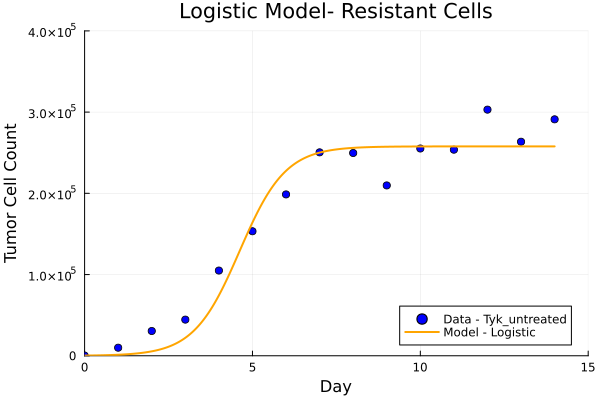


=== Statistical Summary ===
[Logistic] Params: [1.4628383825754607, 257793.50438295747]
[Logistic] BIC: 307.9497259714967 | SSR: 8.61661861299161e9


In [15]:
poster_tyk_untreated = singleModel(
    "Tyk_untreated", x_all, y_tyk_untreated, u0_all,
    "Logistic", [1.5, 250000], [(0.1,5), (100000,350000)], logistic_growth,
    Rodas5(), (0.0,15.0)
    )

===== Solving for Model 1: Logistic =====


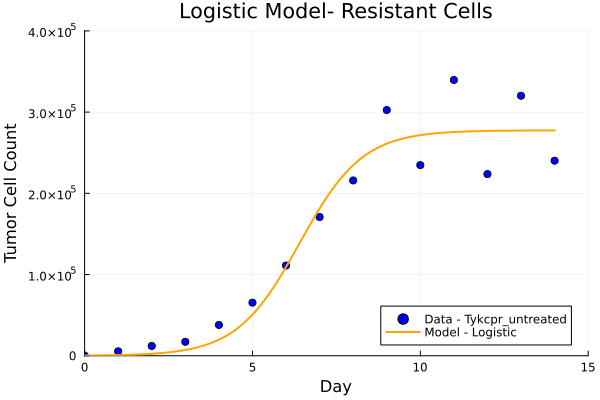


=== Statistical Summary ===
[Logistic] Params: [1.0660127793008605, 277519.58449298074]
[Logistic] BIC: 315.7204708305173 | SSR: 1.4465151221978085e10


In [16]:
poster_tykcpr_untreated = singleModel(
    "Tykcpr_untreated", x_all, y_tykcpr_untreated, u0_all,
    "Logistic", [1.5, 250000], [(0.1,5), (100000,350000)], logistic_growth,
    Rodas5(), (0.0,15.0)
    )

===== Solving for Model 1: Logistic =====


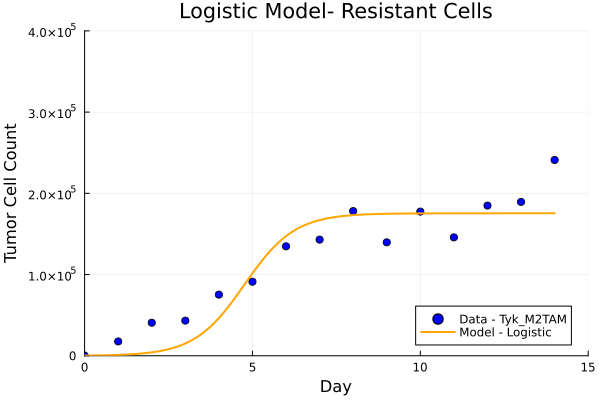


=== Statistical Summary ===
[Logistic] Params: [1.3370961344838632, 175425.5322757178]
[Logistic] BIC: 311.34608024013426 | SSR: 1.0806160123729813e10


In [17]:
poster_tyk_M2TAM = singleModel(
    "Tyk_M2TAM", x_all, y_tyk_M2TAM, u0_all,
    "Logistic", [1.5, 250000], [(0.1,5), (100000,400000)], logistic_growth,
    Rodas5(), (0.0,15.0)
    )

===== Solving for Model 1: Logistic =====


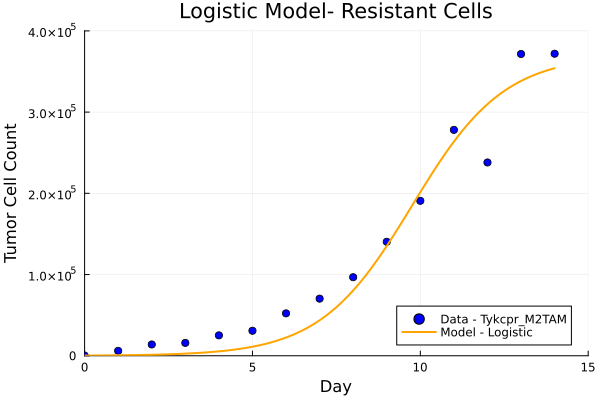


=== Statistical Summary ===
[Logistic] Params: [0.7293340976004314, 370045.9790628168]
[Logistic] BIC: 310.0673558507418 | SSR: 9.92312667577108e9


In [18]:
poster_tykcpr_M2TAM = singleModel(
    "Tykcpr_M2TAM", x_all, y_tykcpr_M2TAM, u0_all,
    "Logistic", [1.5, 250000], [(0.1,5), (100000,400000)], logistic_growth,
    Rodas5(), (0.0,15.0)
    )